## Pytorch

In [112]:
import numpy as np
import pandas as pd
import librosa
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
from pathlib import Path
import copy

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
base_path = Path("..")

processed_path = base_path / "data" / "processed"
wet_path = processed_path / "wet"
data_split_path = processed_path / "data_split"

train_path = data_split_path / "train.csv"
val_path = data_split_path / "val.csv"
test_path = data_split_path / "test.csv"

In [81]:
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
train_df.head()

,source_id,wet_path,room_size,wet_level,rate_hz,depth,room_size_norm,wet_level_norm,rate_hz_norm,depth_norm
0,Bridge_1-0,..\data\processed\wet\Bridge_1-0_v0.wav,0.374540,0.570429,3.793973,0.598658,0.374540,0.950714,0.731994,0.598658
1,Bridge_1-0,..\data\processed\wet\Bridge_1-0_v1.wav,0.156019,0.093597,0.761376,0.866176,0.156019,0.155995,0.058084,0.866176
2,Bridge_1-0,..\data\processed\wet\Bridge_1-0_v2.wav,0.601115,0.424844,0.592630,0.969910,0.601115,0.708073,0.020584,0.969910
3,Bridge_1-0,..\data\processed\wet\Bridge_1-0_v3.wav,0.832443,0.127403,1.318212,0.183405,0.832443,0.212339,0.181825,0.183405
4,Bridge_1-0,..\data\processed\wet\Bridge_1-0_v4.wav,0.304242,0.314854,2.443753,0.291229,0.304242,0.524756,0.431945,0.291229


In [4]:
audio_path = train_df.loc[0, "wet_path"]

y, sr = librosa.load(
    audio_path,
    sr=None
)

print(audio_path)
print(y.shape)
print(sr)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


..\data\processed\wet\Bridge_1-0_v0.wav
(240000,)
48000


#### Матрица частот и временных отрезков

In [5]:
mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)

mel_spec.shape

(128, 469)

In [6]:
mel_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

print(mel_db.shape)
print(mel_db.min())
print(mel_db.max())

(128, 469)
-80.0
0.0


#### Нормирование

In [7]:
mel_norm = (mel_db + 80) / 80
print(mel_norm.min())
print(mel_norm.max())
print(mel_norm.shape)

0.0
1.0
(128, 469)


#### Тензоры

In [8]:
mel_tensor = torch.from_numpy(mel_norm).unsqueeze(0)

print(mel_tensor.shape)
mel_tensor.dtype

torch.Size([1, 128, 469])


torch.float32

#### Класс для перевода в тензоры

In [24]:
class GuitarFXDataset(Dataset):

    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]
        audio_path = row["wet_path"]

        y, sr = librosa.load(
            audio_path,
            sr=None
        )


        target_length = 5 * sr

        if len(y) > target_length:
            y = y[:target_length]

        elif len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)))


        mel_spec = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=2048,
            hop_length=512,
            n_mels=128
        )

        mel_db = librosa.power_to_db(
            mel_spec,
            ref=np.max
        )

        mel_norm = (mel_db + 80) / 80

        mel_tensor = torch.from_numpy(mel_norm).unsqueeze(0)

        targets_cols = [
            "room_size_norm",
            "wet_level_norm",
            "rate_hz_norm",
            "depth_norm"
        ]   

        target = row[targets_cols].to_numpy(dtype=np.float32)
        target_tensor = torch.from_numpy(target)


        return mel_tensor, target_tensor

In [25]:
train_dataset = GuitarFXDataset(train_df)

x, y = train_dataset[0]

print(x.shape)
print(x.dtype)

print(y.shape)
print(y.dtype)
print(y)




torch.Size([1, 128, 469])
torch.float32
torch.Size([4])
torch.float32
tensor([0.3745, 0.9507, 0.7320, 0.5987])


#### Data loader

In [26]:

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

x_batch, y_batch = next(iter(train_loader))

print(x_batch.shape)
print(y_batch.shape)

torch.Size([16, 1, 128, 469])
torch.Size([16, 4])


In [30]:
conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=16,
    kernel_size=3,
    padding=1
)

out = conv1(x_batch)

print(x_batch.shape)
print(out.shape)

torch.Size([16, 1, 128, 469])
torch.Size([16, 16, 128, 469])


#### Выделяю самые важные признаки

In [ ]:
pool = nn.MaxPool2d(kernel_size=2)
pooled = pool(out)

print(out.shape)
print(pooled.shape)

torch.Size([16, 16, 128, 469])
torch.Size([16, 16, 64, 234])


#### Нелинейность (-n -> 0)

In [33]:
relu = nn.ReLU()
activated = relu(out)

print(out.shape)
print(activated.shape)

torch.Size([16, 16, 128, 469])
torch.Size([16, 16, 128, 469])


#### Все вместе

In [35]:
conv_out = conv1(x_batch)
relu_out = relu(conv_out)
pool_out = pool(relu_out)

x_batch.shape, conv_out.shape, relu_out.shape, pool_out.shape

(torch.Size([16, 1, 128, 469]),
 torch.Size([16, 16, 128, 469]),
 torch.Size([16, 16, 128, 469]),
 torch.Size([16, 16, 64, 234]))

In [37]:
conv2 = nn.Conv2d(
    in_channels=16,
    out_channels=32,
    kernel_size=3,
    padding=1
)

relu2 = nn.ReLU()
pool2 = nn.MaxPool2d(kernel_size=2)

conv2_out = conv2(pool_out)
relu2_out = relu2(conv2_out)
pool2_out = pool2(relu2_out)

print(conv2_out.shape)
print(relu2_out.shape)
print(pool2_out.shape)


torch.Size([16, 32, 64, 234])
torch.Size([16, 32, 64, 234])
torch.Size([16, 32, 32, 117])


#### Развертывание

In [38]:
flatten = nn.Flatten()
flat_out = flatten(pool2_out)

print(pool2_out.shape)
print(flat_out.shape)

torch.Size([16, 32, 32, 117])
torch.Size([16, 119808])


In [40]:
conv3 = nn.Conv2d(
    in_channels=32,
    out_channels=64,
    kernel_size=3,
    padding=1
)

relu3 = nn.ReLU()
pool3 = nn.MaxPool2d(kernel_size=2)

conv3_out = conv3(pool2_out)
relu3_out = relu3(conv3_out)
pool3_out = pool3(relu3_out)

print(pool3_out.shape)

torch.Size([16, 64, 16, 58])


In [41]:
flat3 = flatten(pool3_out)

print(pool3_out.shape)
print(flat3.shape)

torch.Size([16, 64, 16, 58])
torch.Size([16, 59392])


In [42]:
adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

adaptive_out = adaptive_pool(pool3_out)

print(pool3_out.shape)
print(adaptive_out.shape)

torch.Size([16, 64, 16, 58])
torch.Size([16, 64, 4, 4])


In [46]:
flat = nn.Flatten()
flat_out = flat(adaptive_out)

fc1 = nn.Linear(
    in_features=1024,
    out_features=128
)

fc_relu = nn.ReLU()

hidden = fc_relu(fc1(flat_out))

fc2 = nn.Linear(
    in_features = 128,
    out_features=4
)

preds = fc2(hidden)

print(flat_out.shape)
print(hidden.shape)
print(preds.shape)
print(preds[0])

torch.Size([16, 1024])
torch.Size([16, 128])
torch.Size([16, 4])
tensor([-0.1189, -0.0336,  0.0384,  0.0427], grad_fn=<SelectBackward0>)


#### Модель

In [69]:
class GuitarFXCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.flat = nn.Flatten()

        self.fc1 = nn.Linear(
            in_features=1024,
            out_features=128
        )

        self.fc_relu = nn.ReLU()

        self.fc2 = nn.Linear(
            in_features=128,
            out_features=4
        )

        


    def forward(self, x):

        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        x = self.adaptive_pool(x)
        x = self.flat(x)

        x = self.fc1(x)
        x = self.fc_relu(x)

        x = self.fc2(x)

        return x

In [70]:
model = GuitarFXCNN()
out = model(x_batch)

print(x_batch.shape)
print(out.shape)

torch.Size([16, 1, 128, 469])
torch.Size([16, 4])


In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

torch.Size([16, 1, 3, 3])
torch.Size([16, 1, 3, 3])


In [77]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

optimizer.zero_grad()

preds = model(x_batch)

loss = criterion(preds, y_batch)


loss.backward()

weight_before = model.conv1.weight[0, 0, 0, 0].item()

optimizer.step()

weight_after = model.conv1.weight[0, 0, 0, 0].item()


print("Loss:", loss.item())
print("Weight before:", weight_before)
print("Weight after:", weight_after)

Loss: 0.32404908537864685
Weight before: 0.2796608507633209
Weight after: 0.27866730093955994


In [80]:
torch.manual_seed(42)

model = GuitarFXCNN()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

#### 1 эпоха

In [79]:
running_loss = 0.0

for x_batch, y_batch in train_loader:

    optimizer.zero_grad()

    preds = model(x_batch)

    loss = criterion(preds, y_batch)

    loss.backward()

    optimizer.step()
    
    running_loss += loss.item()


mean_train_loss = running_loss / len(train_loader)

print(mean_train_loss)

0.09047232341292678


In [83]:
val_dataset = GuitarFXDataset(val_df)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

x_val, y_val = next(iter(val_loader))

print(x_val.shape)
print(y_val.shape)

torch.Size([16, 1, 128, 469])
torch.Size([16, 4])


#### Проверка

In [84]:
model.eval()

running_val_loss = 0.0

with torch.no_grad():

    for x_batch, y_batch in val_loader:

        preds = model(x_batch)

        loss = criterion(preds, y_batch)

        running_val_loss += loss.item()


mean_val_loss = running_val_loss / len(val_loader)

print(mean_val_loss)

0.3466425971551375


In [85]:
model.eval()

running_train_eval_loss = 0.0

with torch.no_grad():

    for x_batch, y_batch in train_loader:

        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        running_train_eval_loss += loss.item()


mean_train_eval_loss = running_train_eval_loss / len(train_loader)

print(mean_train_eval_loss)

0.3463733858422728


#### Еще одна попытка

In [88]:
torch.manual_seed(42)

model = GuitarFXCNN()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

model.train()

running_loss = 0.0
batch_losses = []

for batch_idx, (x_batch, y_batch) in enumerate(train_loader):

    optimizer.zero_grad()

    pred = model(x_batch)

    loss = criterion(pred, y_batch)

    loss.backward()
    
    optimizer.step()
        
    running_loss += loss.item()

    batch_losses.append(loss.item())

    if batch_idx % 10 == 0:
        print(batch_idx, loss.item())

mean_train_loss = running_loss / len(train_loader)

print("Mean train loss:", mean_train_loss)

0 0.37145090103149414
10 0.09348458796739578
20 0.07614924013614655
30 0.09066987037658691
40 0.0667654275894165
50 0.07293111085891724
60 0.09991943836212158
70 0.08010044693946838
80 0.08450543880462646
90 0.08004298061132431
100 0.06346045434474945
110 0.09326502680778503
120 0.08897075802087784
130 0.06980369985103607
140 0.08139766752719879
150 0.10039056837558746
Mean train loss: 0.09047232341292678


In [89]:
model.eval()

running_train_eval_loss = 0.0

with torch.no_grad():
    for x_batch, y_batch in train_loader:
        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        running_train_eval_loss += loss.item()

mean_train_eval_loss = running_train_eval_loss / len(train_loader)

print("Train eval loss:", mean_train_eval_loss)

Train eval loss: 0.08042294941595848


In [90]:
model.eval()

running_val_loss = 0.0

with torch.no_grad():
    for x_batch, y_batch in val_loader:
        preds = model(x_batch)
        
        loss = criterion(preds, y_batch)
        
        running_val_loss += loss.item()
        
        
mean_val_loss = running_val_loss / len(val_loader)
        
print(mean_val_loss)

0.08222738269603613


In [92]:
def train_one_epoch(model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in train_loader:

        optimizer.zero_grad()

        pred = model(x_batch)

        loss = criterion(pred, y_batch)

        loss.backward()
        
        optimizer.step()
            
        running_loss += loss.item()


    mean_train_loss = running_loss / len(train_loader)

    return mean_train_loss



In [93]:
def validate(model, val_loader, criterion):
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            preds = model(x_batch)
            
            loss = criterion(preds, y_batch)
            
            running_val_loss += loss.item()
            
            
    mean_val_loss = running_val_loss / len(val_loader)
            
    return mean_val_loss

#### Пробую 3 эпохи

In [94]:
torch.manual_seed(42)

model = GuitarFXCNN()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 3

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss = validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/3 | Train Loss: 0.0905 | Val Loss: 0.0822
Epoch 2/3 | Train Loss: 0.0796 | Val Loss: 0.0762
Epoch 3/3 | Train Loss: 0.0734 | Val Loss: 0.0715


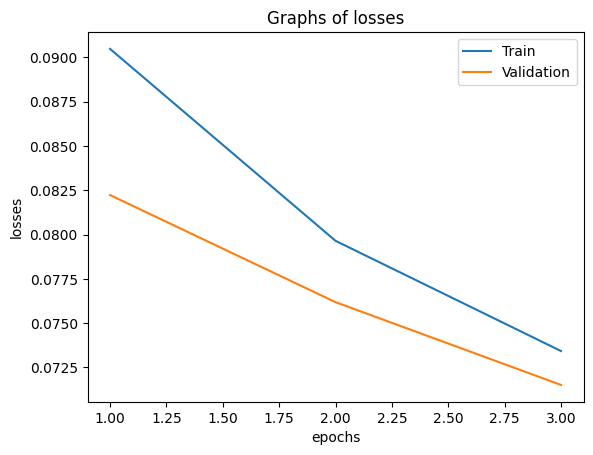

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.plot(epochs, train_losses, label="Train")
plt.plot(epochs, val_losses, label="Validation")

plt.xlabel("epoch")
plt.ylabel("losses")
plt.title("Graphs of losses")
plt.legend()
plt.show()

In [97]:

additional_epochs = 5
completed_epochs = len(train_losses)
total_e = completed_epochs + additional_epochs

for epoch in range(additional_epochs):

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss = validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + completed_epochs + 1}/{total_e} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 4/8 | Train Loss: 0.0666 | Val Loss: 0.0640
Epoch 5/8 | Train Loss: 0.0580 | Val Loss: 0.0591
Epoch 6/8 | Train Loss: 0.0542 | Val Loss: 0.0583
Epoch 7/8 | Train Loss: 0.0516 | Val Loss: 0.0517
Epoch 8/8 | Train Loss: 0.0482 | Val Loss: 0.0482


In [ ]:
additional_epochs = 5
completed_epochs = len(train_losses)
total_epochs = completed_epochs + additional_epochs

for epoch in range(additional_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss = validate(
        model,
        val_loader,
        criterion
    )



    train_losses.append(train_loss)
    val_losses.append(val_loss)

    current_epoch = completed_epochs + epoch + 1

    print(
        f"Epoch {current_epoch}/{total_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 10/14 | Train Loss: 0.0362 | Val Loss: 0.0394
Epoch 11/14 | Train Loss: 0.0334 | Val Loss: 0.0366
Epoch 12/14 | Train Loss: 0.0311 | Val Loss: 0.0311
Epoch 13/14 | Train Loss: 0.0286 | Val Loss: 0.0284
Epoch 14/14 | Train Loss: 0.0267 | Val Loss: 0.0275


In [103]:
print(len(train_losses))
print(len(val_losses))

best_val_loss = val_losses[-1]
best_model_state = copy.deepcopy(model.state_dict())

14
14


In [106]:
additional_epochs = 3
completed_epochs = len(train_losses)
total_epochs = completed_epochs + additional_epochs

for epoch in range(additional_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss = validate(
        model,
        val_loader,
        criterion
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    current_epoch = completed_epochs + epoch + 1

    print(
        f"Epoch {current_epoch}/{total_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 25/27 | Train Loss: 0.0182 | Val Loss: 0.0238
Epoch 26/27 | Train Loss: 0.0180 | Val Loss: 0.0181
Epoch 27/27 | Train Loss: 0.0178 | Val Loss: 0.0176


#### с early stopping

In [108]:
additional_epochs = 20
completed_epochs = len(train_losses)
total_epochs = completed_epochs + additional_epochs

patience = 5
epochs_without_improvement = 0

for epoch in range(additional_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss = validate(
        model,
        val_loader,
        criterion
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    train_losses.append(train_loss)
    val_losses.append(val_loss)




    current_epoch = completed_epochs + epoch + 1

    print(
        f"Epoch {current_epoch}/{total_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {current_epoch}")
        break

Epoch 28/47 | Train Loss: 0.0170 | Val Loss: 0.0187
Epoch 29/47 | Train Loss: 0.0170 | Val Loss: 0.0171
Epoch 30/47 | Train Loss: 0.0159 | Val Loss: 0.0165
Epoch 31/47 | Train Loss: 0.0156 | Val Loss: 0.0162
Epoch 32/47 | Train Loss: 0.0151 | Val Loss: 0.0169
Epoch 33/47 | Train Loss: 0.0154 | Val Loss: 0.0177
Epoch 34/47 | Train Loss: 0.0149 | Val Loss: 0.0165
Epoch 35/47 | Train Loss: 0.0138 | Val Loss: 0.0165
Epoch 36/47 | Train Loss: 0.0136 | Val Loss: 0.0166
Early stopping at epoch 36


In [109]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [110]:
best_val_check = validate(
    model,
    val_loader,
    criterion
)

print("Best Val MSE:", best_val_check)
print("Stored Best Val MSE:", best_val_loss)

Best Val MSE: 0.01623531605935458
Stored Best Val MSE: 0.01623531605935458


In [111]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for x_batch, y_batch in val_loader:

        preds = model(x_batch)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

print(all_preds.shape)
print(all_targets.shape)

(515, 4)
(515, 4)


In [113]:
results = []

target_names = [
    "room_size_norm",
    "wet_level_norm",
    "rate_hz_norm",
    "depth_norm"
]

for i, target_name in enumerate(target_names):

    y_true = all_targets[:, i]
    y_pred = all_preds[:, i]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results.append({
        "target": target_name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

metrics_df = pd.DataFrame(results)
metrics_df

,target,mae,rmse,r2
0,room_size_norm,0.120940,0.158385,0.706648
1,wet_level_norm,0.081950,0.107011,0.858803
2,rate_hz_norm,0.097279,0.134982,0.789841
3,depth_norm,0.075913,0.101479,0.876089


In [114]:
mean_mae = metrics_df["mae"].mean()
mean_rmse = metrics_df["rmse"].mean()
mean_r2 = metrics_df["r2"].mean()

print("Validation Mean MAE:", mean_mae)
print("Validation Mean RMSE:", mean_rmse)
print("Validation Mean R²:", mean_r2)

Validation Mean MAE: 0.09402026236057281
Validation Mean RMSE: 0.12546411399951848
Validation Mean R²: 0.8078452199697495


In [115]:
models_path = base_path / "models"
models_path.mkdir(parents=True, exist_ok=True)

In [116]:
checkpoint_path = models_path / "cnn_best_checkpoint.pt"

torch.save(
    {
        "model_state_dict": best_model_state,
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "epochs_completed": len(train_losses),
    },
    checkpoint_path
)

print(checkpoint_path)

..\models\cnn_best_checkpoint.pt


In [117]:
checkpoint_path.exists()

True

In [118]:
print("Epochs:", len(train_losses))
print("Best Val Loss:", best_val_loss)
print("Current Val Loss:", validate(model, val_loader, criterion))

Epochs: 36
Best Val Loss: 0.01623531605935458
Current Val Loss: 0.01623531605935458


In [119]:
test_df = pd.read_csv(test_path)
test_dataset = GuitarFXDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

x_test, y_test = next(iter(test_loader))

print(x_test.shape)
print(y_test.shape)

torch.Size([16, 1, 128, 469])
torch.Size([16, 4])


In [120]:
model.eval()

test_preds = []
test_targets = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:

        preds = model(x_batch)

        test_preds.append(preds.cpu().numpy())
        test_targets.append(y_batch.cpu().numpy())

test_preds = np.concatenate(test_preds, axis=0)
test_targets = np.concatenate(test_targets, axis=0)

print(test_preds.shape)
print(test_targets.shape)

(520, 4)
(520, 4)


In [121]:
target_names = [
    "room_size_norm",
    "wet_level_norm",
    "rate_hz_norm",
    "depth_norm"
]

test_results = []

for i, target_name in enumerate(target_names):

    y_true = test_targets[:, i]
    y_pred = test_preds[:, i]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    test_results.append({
        "target": target_name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

test_metrics_df = pd.DataFrame(test_results)

test_mean_mae = test_metrics_df["mae"].mean()
test_mean_rmse = test_metrics_df["rmse"].mean()
test_mean_r2 = test_metrics_df["r2"].mean()

print("Test Mean MAE:", test_mean_mae)
print("Test Mean RMSE:", test_mean_rmse)
print("Test Mean R²:", test_mean_r2)

test_metrics_df

Test Mean MAE: 0.09375863149762154
Test Mean RMSE: 0.12702975018850113
Test Mean R²: 0.8023663908243179


,target,mae,rmse,r2
0,room_size_norm,0.113531,0.151843,0.719649
1,wet_level_norm,0.090672,0.118700,0.841854
2,rate_hz_norm,0.099963,0.143456,0.755295
3,depth_norm,0.070869,0.094120,0.892668


In [122]:
predictions_path = base_path / "reports" / "predictions"
predictions_path.mkdir(parents=True, exist_ok=True)

np.savez(
    predictions_path / "cnn_test_predictions.npz",
    preds=test_preds,
    targets=test_targets
)

In [123]:
print((predictions_path / "cnn_test_predictions.npz").exists())

True
